In [33]:
#Librerías
import numpy as np
import pandas as pd

**Etapa 3 - Limpieza y Transformación de datos**

In [34]:
# -----------------------------------------------------------------------------
# Carga de datos originales y diccionario
# -----------------------------------------------------------------------------
df_raw = pd.read_csv("REG02_EPHC_ANUAL_2025.csv", sep=';', low_memory=False)
diccionario = pd.read_excel("diccionario_EPHC_ANUAL_2025.xls")

df = df_raw.copy()
print(f"Dimensiones iniciales: {df.shape[0]} filas, {df.shape[1]} columnas")

Dimensiones iniciales: 55934 filas, 213 columnas


In [35]:
# -----------------------------------------------------------------------------
# 1. Creación de Clave Primaria y verificación de duplicados
# -----------------------------------------------------------------------------
df["ID_PERSONA"] = (
    df["UPM"].astype(str)
    + "_"
    + df["NVIVI"].astype(str)
    + "_"
    + df["NHOGA"].astype(str)
    + "_"
    + df["L02"].astype(str)
)

duplicados_exactos = df.duplicated().sum()
duplicados_id = df.duplicated(subset=["ID_PERSONA"]).sum()

print(f"Duplicados exactos: {duplicados_exactos}")
print(f"Duplicados por ID_PERSONA: {duplicados_id}")
assert duplicados_id == 0, "Error: Existen claves primarias duplicadas."

Duplicados exactos: 0
Duplicados por ID_PERSONA: 0


In [36]:
# -----------------------------------------------------------------------------
# 2. Reemplazo de códigos de falta de respuesta (Valores centinela)
# -----------------------------------------------------------------------------
# Limpieza de valores como 999999999 o 99 en variables de ingreso y educación
centinelas_ingreso = [999999999, 99999999, 999999]
centinelas_educ = [99]

if "INGPRINC" in df.columns:
    df["INGPRINC"] = df["INGPRINC"].replace(centinelas_ingreso, np.nan)

if "ED01" in df.columns:
    df["ED01"] = df["ED01"].replace(centinelas_educ, np.nan)

In [37]:
# -----------------------------------------------------------------------------
# 3. Normalización de tipos de datos y formatos de texto
# -----------------------------------------------------------------------------
cols_categoricas = ["AREA", "P02_SEXO", "P06"]
for col in cols_categoricas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Normalizar columnas de ingreso a float64, y ED01 (años de estudio)
cols_num = ["INGPRINC", "INGTOT", "FEX", "ED01"]
for col in cols_num:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [38]:
# -----------------------------------------------------------------------------
# 4. Tratamiento de inconsistencias lógicas e imputación
# -----------------------------------------------------------------------------
# Inconsistencia: Escolaridad > Edad - 5
if "ED01" in df.columns and "P06" in df.columns:
    mask_inconsistente = df["ED01"] > (df["P06"] - 5)
    print(
        f"Registros con inconsistencia Edad vs Escolaridad: {mask_inconsistente.sum()}"
    )
    df.loc[mask_inconsistente, "ED01"] = np.maximum(
        0, df.loc[mask_inconsistente, "P06"] - 6
    )

# Imputación de ED01 (Años de estudio) por la mediana del grupo de edad
if "ED01" in df.columns:
    df["ED01"] = df.groupby(pd.cut(df["P06"], bins=[0, 14, 24, 49, 64, 100]))[
        "ED01"
    ].transform(lambda x: x.fillna(x.median()))

Registros con inconsistencia Edad vs Escolaridad: 45097


/tmp/ipykernel_1919/1520641422.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["ED01"] = df.groupby(pd.cut(df["P06"], bins=[0, 14, 24, 49, 64, 100]))[


In [39]:
# -----------------------------------------------------------------------------
# 5. Creación de variables derivadas
# -----------------------------------------------------------------------------
# Mapeo y conversión numérica de ingresos desde e01aimde / E01A y ipcm
if "e01aimde" in df.columns:
    df["INGPRINC"] = pd.to_numeric(
        df["e01aimde"].astype(str).str.replace(",", ".").str.strip(),
        errors="coerce",
    ).fillna(0)
elif "E01A" in df.columns:
    df["INGPRINC"] = pd.to_numeric(
        df["E01A"].astype(str).str.replace(",", ".").str.strip(),
        errors="coerce",
    ).fillna(0)

if "ipcm" in df.columns:
    df["INGTOT"] = pd.to_numeric(
        df["ipcm"].astype(str).str.replace(",", ".").str.strip(),
        errors="coerce",
    ).fillna(0)

# Población en Edad de Trabajar (PET >= 15 años usando P02)
df["PET"] = np.where(df["P02"] >= 15, 1, 0)


# Recodificación del Nivel Educativo (usando añoest o ED01)
def recodificar_educacion(row):
    col_edu = "añoest" if "añoest" in row else "ED01"
    anos = row.get(col_edu, np.nan)
    try:
        anos = float(str(anos).replace(",", "."))
    except (ValueError, TypeError):
        anos = np.nan

    if pd.isna(anos):
        return "Sin Instrucción"
    elif anos <= 2:
        return "1. Sin Instrucción / Inicial"
    elif 3 <= anos <= 9:
        return "2. Educación Básica"
    elif 10 <= anos <= 12:
        return "3. Educación Media"
    else:
        return "4. Superior / Universitaria"


df["NIVEL_EDUCATIVO_REC"] = df.apply(recodificar_educacion, axis=1)

# Categorización por Tramos de Edad (usando P02)
df["TRAMO_EDAD"] = pd.cut(
    df["P02"],
    bins=[-1, 14, 24, 49, 64, 120],
    labels=["Menores (<15)", "15-24", "25-49", "50-64", "65+"],
)

# Variable de Informalidad Laboral (1 = Informal, 2 = Formal según INE)
if "informalidad" in df.columns:
    df["INFORMAL_LABORAL"] = np.where(df["informalidad"] == 1, 1, 0)

# Subconjunto de trabajo: PEA Ocupada con ingreso laboral válido (> 0)
df_pea_ocupada = df[(df["PET"] == 1) & (df["INGPRINC"] > 0)].copy()

# Transformación logarítmica del ingreso principal
df_pea_ocupada["LN_INGPRINC"] = np.log(df_pea_ocupada["INGPRINC"])

In [40]:
# -----------------------------------------------------------------------------
# 6. Auditoría final de dataset transformado
# -----------------------------------------------------------------------------
print("\n--- RESUMEN DE PROCESAMIENTO ---")
print(f"Total registros dataset general transformado: {len(df)}")
print(f"Total registros submuestra PEA Ocupada con ingresos: {len(df_pea_ocupada)}")
print("\nDistribución por Nivel Educativo Recodificado (PEA Ocupada):")
print(df_pea_ocupada["NIVEL_EDUCATIVO_REC"].value_counts(normalize=True) * 100)


--- RESUMEN DE PROCESAMIENTO ---
Total registros dataset general transformado: 55934
Total registros submuestra PEA Ocupada con ingresos: 26459

Distribución por Nivel Educativo Recodificado (PEA Ocupada):
NIVEL_EDUCATIVO_REC
2. Educación Básica             38.576666
4. Superior / Universitaria     29.929325
3. Educación Media              27.450017
1. Sin Instrucción / Inicial     4.043993
Name: proportion, dtype: float64


In [41]:
# Exportar datasets limpios para la Etapa 4 (EDA y Análisis Inferencial)
df.to_csv("REG02_EPHC_ANUAL_2025_CLEAN_FULL.csv", index=False)
df_pea_ocupada.to_csv("REG02_EPHC_ANUAL_2025_CLEAN_PEA.csv", index=False)
print("\n Archivos limpios generados exitosamente.")


 Archivos limpios generados exitosamente.


**Etapa 4 -Análisis univariado y bivariado**

In [42]:
# =============================================================================
# ETAPA 4 - ANÁLISIS UNIVARIADO Y BIVARIADO (SOLO ESTADÍSTICAS)
# =============================================================================

# Importar librerías adicionales necesarias
from scipy import stats
import numpy as np
import pandas as pd

# Cargar el dataset limpio de la PEA Ocupada (generado en la Etapa 3)
df_pea = pd.read_csv("REG02_EPHC_ANUAL_2025_CLEAN_PEA.csv", low_memory=False)

# -----------------------------------------------------------------------------
# 4.1. Análisis Univariado Numérico
# -----------------------------------------------------------------------------
def analizar_numerica(df, columna):
    """
    Calcula estadísticos descriptivos completos para una variable numérica dada.
    """
    data = df[columna].dropna()

    # Cálculos estadísticos
    media = data.mean()
    mediana = data.median()
    moda = data.mode()[0]
    std = data.std()
    cv = (std / media) * 100 if media != 0 else np.nan
    min_val, max_val = data.min(), data.max()
    q25, q50, q75 = data.quantile([0.25, 0.50, 0.75])
    iqr = q75 - q25
    p5, p95 = data.quantile([0.05, 0.95])
    asimetria = stats.skew(data, bias=False)
    curtosis = stats.kurtosis(data, bias=False)

    # Imprimir Reporte Estadístico
    print(f"--- ESTADÍSTICOS DE: {columna} ---")
    print(f"Media: {media:.2f} | Mediana: {mediana:.2f} | Moda: {moda:.2f}")
    print(f"Desv. Estándar: {std:.2f} | Coef. Variación: {cv:.2f}%")
    print(f"Mín: {min_val:.2f} | Máx: {max_val:.2f} | Rango Intercuartílico (IQR): {iqr:.2f}")
    print(f"Percentiles -> P5: {p5:.2f} | P25: {q25:.2f} | P50: {q50:.2f} | P75: {q75:.2f} | P95: {p95:.2f}")
    print(f"Forma -> Asimetría: {asimetria:.2f} | Curtosis: {curtosis:.2f}\n")

# Aplicar función a variables de interés
print("ANÁLISIS UNIVARIADO: INGRESOS (Sin transformación)")
analizar_numerica(df_pea, 'INGPRINC')

print("ANÁLISIS UNIVARIADO: LOGARITMO DE INGRESOS (Transformado)")
analizar_numerica(df_pea, 'LN_INGPRINC')

print("ANÁLISIS UNIVARIADO: AÑOS DE ESTUDIO")
analizar_numerica(df_pea, 'ED01')

# -----------------------------------------------------------------------------
# 4.2. Análisis Univariado Categórico
# -----------------------------------------------------------------------------
def analizar_categorica(df, columna):
    """
    Muestra frecuencias absolutas, relativas, porcentaje acumulado
    para variables categóricas.
    """
    freq_abs = df[columna].value_counts()
    freq_rel = df[columna].value_counts(normalize=True) * 100
    freq_acum = freq_rel.cumsum()

    df_freq = pd.DataFrame({
        'Frecuencia Absoluta': freq_abs,
        'Frecuencia Relativa (%)': freq_rel.round(2),
        'Frecuencia Acumulada (%)': freq_acum.round(2)
    })

    print(f"--- ANÁLISIS DE CONCENTRACIÓN: {columna} ---")
    print(df_freq, "\n")

# Aplicar a variables categóricas clave
analizar_categorica(df_pea, 'NIVEL_EDUCATIVO_REC')
analizar_categorica(df_pea, 'INFORMAL_LABORAL')

# -----------------------------------------------------------------------------
# 4.3. Análisis Bivariado: Numérica vs Numérica
# -----------------------------------------------------------------------------
print("\n--- CORRELACIÓN: INGRESOS, EDAD, AÑOS DE ESTUDIO ---")
cols_corr = ['INGPRINC', 'LN_INGPRINC', 'ED01', 'P02']
df_corr = df_pea[cols_corr].dropna()

# Matriz de correlación (Pearson)
corr_matrix = df_corr.corr(method='pearson')
print("Matriz de Correlación de Pearson:")
print(corr_matrix, "\n")

# -----------------------------------------------------------------------------
# 4.4. Análisis Bivariado: Numérica vs Categórica
# -----------------------------------------------------------------------------
print("\n--- DISTRIBUCIÓN DE INGRESOS POR NIVEL EDUCATIVO ---")
# Estadísticos resumen por grupo
print(df_pea.groupby('NIVEL_EDUCATIVO_REC')['INGPRINC'].describe())

# -----------------------------------------------------------------------------
# 4.5. Análisis Bivariado: Categórica vs Categórica
# -----------------------------------------------------------------------------
print("\n--- TABLA DE CONTINGENCIA: EDUCACIÓN VS INFORMALIDAD ---")
crosstab_edu_inf = pd.crosstab(
    df_pea['NIVEL_EDUCATIVO_REC'],
    df_pea['INFORMAL_LABORAL'],
    normalize='index'
) * 100

print("Porcentaje de Informalidad por Nivel Educativo (Frecuencias Relativas por Fila):")
print(crosstab_edu_inf.round(2))

ANÁLISIS UNIVARIADO: INGRESOS (Sin transformación)
--- ESTADÍSTICOS DE: INGPRINC ---
Media: 3112449.28 | Mediana: 2500000.00 | Moda: 3000000.00
Desv. Estándar: 7466256.67 | Coef. Variación: 239.88%
Mín: 453.51 | Máx: 536806006.58 | Rango Intercuartílico (IQR): 2280583.09
Percentiles -> P5: 300000.00 | P25: 1204341.53 | P50: 2500000.00 | P75: 3484924.62 | P95: 7327466.29
Forma -> Asimetría: 40.17 | Curtosis: 2275.89

ANÁLISIS UNIVARIADO: LOGARITMO DE INGRESOS (Transformado)
--- ESTADÍSTICOS DE: LN_INGPRINC ---
Media: 14.50 | Mediana: 14.73 | Moda: 14.91
Desv. Estándar: 1.01 | Coef. Variación: 6.97%
Mín: 6.12 | Máx: 20.10 | Rango Intercuartílico (IQR): 1.06
Percentiles -> P5: 12.61 | P25: 14.00 | P50: 14.73 | P75: 15.06 | P95: 15.81
Forma -> Asimetría: -1.08 | Curtosis: 3.84

ANÁLISIS UNIVARIADO: AÑOS DE ESTUDIO
--- ESTADÍSTICOS DE: ED01 ---
Media: 0.11 | Mediana: 0.00 | Moda: 0.00
Desv. Estándar: 0.31 | Coef. Variación: 287.37%
Mín: 0.00 | Máx: 1.00 | Rango Intercuartílico (IQR): 0.00
P

**Etapa 5 - Análisis descriptivo y exploratorio**


In [43]:
# =============================================================================
# ETAPA 5 - PRUEBAS DE HIPÓTESIS Y ANÁLISIS INFERENCIAL (SOLO ESTADÍSTICAS)
# =============================================================================

from scipy.stats import kruskal, kstest, skew, kurtosis
import pandas as pd

# Cargar el dataset limpio de la PEA Ocupada
df_pea = pd.read_csv("REG02_EPHC_ANUAL_2025_CLEAN_PEA.csv", low_memory=False)

# -----------------------------------------------------------------------------
# 5.1. Verificación de Normalidad (Kolmogorov-Smirnov)
# -----------------------------------------------------------------------------
data_ingreso = df_pea['LN_INGPRINC'].dropna()
ks_statistic, ks_p_value = kstest(data_ingreso, 'norm')

print("--- PRUEBA DE KOLMOGOROV-SMIRNOV ---")
print(f"Estadístico KS: {ks_statistic:.4f} | p-valor: {ks_p_value:.4e}")
if ks_p_value > 0.05:
    print("Los datos siguen una distribución normal.\n")
else:
    print("Los datos NO siguen una distribución normal (justifica usar métodos no paramétricos).\n")

# -----------------------------------------------------------------------------
# 5.2. Prueba de Kruskal-Wallis para comparar ingresos por Nivel Educativo
# -----------------------------------------------------------------------------
grupos_educacion = [group['LN_INGPRINC'].values for name, group in df_pea.groupby('NIVEL_EDUCATIVO_REC')]
stat_kw, p_value_kw = kruskal(*grupos_educacion)

print("--- PRUEBA DE KRUSKAL-WALLIS (Ingresos según Nivel Educativo) ---")
print(f"Estadístico H: {stat_kw:.4f} | p-valor: {p_value_kw:.4e}")
if p_value_kw < 0.05:
    print("Conclusión: Se rechaza la hipótesis nula. Existen diferencias estadísticamente significativas en los ingresos entre los distintos niveles educativos.\n")
else:
    print("Conclusión: No se encuentran diferencias significativas.\n")

# -----------------------------------------------------------------------------
# 5.3. Matriz de Correlación
# -----------------------------------------------------------------------------
cols_analisis = ['INGPRINC', 'LN_INGPRINC', 'ED01', 'P02']
correlation_matrix = df_pea[cols_analisis].corr()

print("--- MATRIZ DE CORRELACIÓN (SE VISUALIZA MÁS ADELANTE) ---")
print(correlation_matrix, "\n")

--- PRUEBA DE KOLMOGOROV-SMIRNOV ---
Estadístico KS: 1.0000 | p-valor: 0.0000e+00
Los datos NO siguen una distribución normal (justifica usar métodos no paramétricos).

--- PRUEBA DE KRUSKAL-WALLIS (Ingresos según Nivel Educativo) ---
Estadístico H: 4803.6135 | p-valor: 0.0000e+00
Conclusión: Se rechaza la hipótesis nula. Existen diferencias estadísticamente significativas en los ingresos entre los distintos niveles educativos.

--- MATRIZ DE CORRELACIÓN ---
             INGPRINC  LN_INGPRINC      ED01       P02
INGPRINC     1.000000     0.406381 -0.074974  0.025342
LN_INGPRINC  0.406381     1.000000 -0.256095 -0.147398
ED01        -0.074974    -0.256095  1.000000  0.073823
P02          0.025342    -0.147398  0.073823  1.000000 



### Etapas 4 y 5: Visualizaciones Individuales

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuración visual global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar dataset evitando la advertencia de tipos de datos mixtos
df_pea = pd.read_csv("REG02_EPHC_ANUAL_2025_CLEAN_PEA.csv", low_memory=False)

#### Figura 1: Distribución del Ingreso Principal

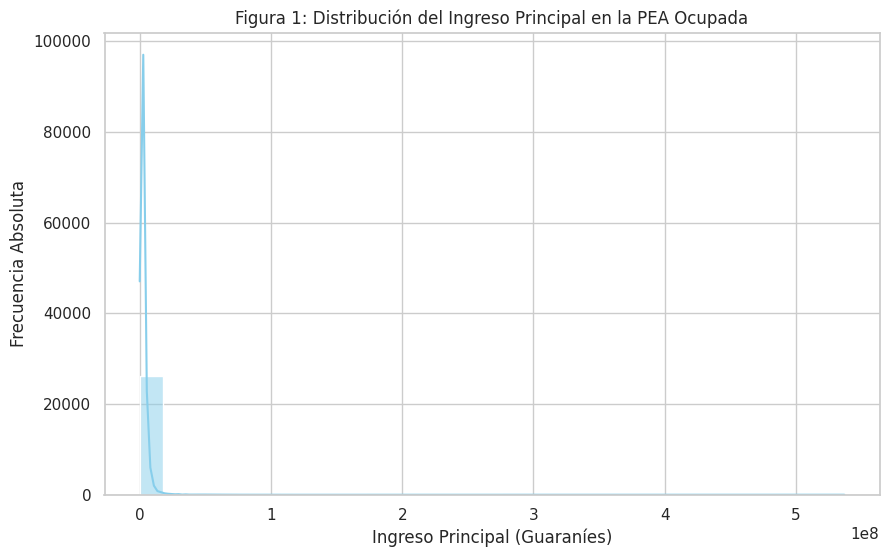

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(df_pea['INGPRINC'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Figura 1: Distribución del Ingreso Principal en la PEA Ocupada')
plt.xlabel('Ingreso Principal (Guaraníes)')
plt.ylabel('Frecuencia Absoluta')
plt.show()

###Interpretación: El gráfico evidencia una marcada asimetría positiva con una larga cola hacia la derecha, mostrando que la mayoría de los trabajadores se concentran en tramos de menores ingresos mientras que una minoría percibe montos extremadamente elevados.

#### Figura 2: Densidad del Logaritmo del Ingreso

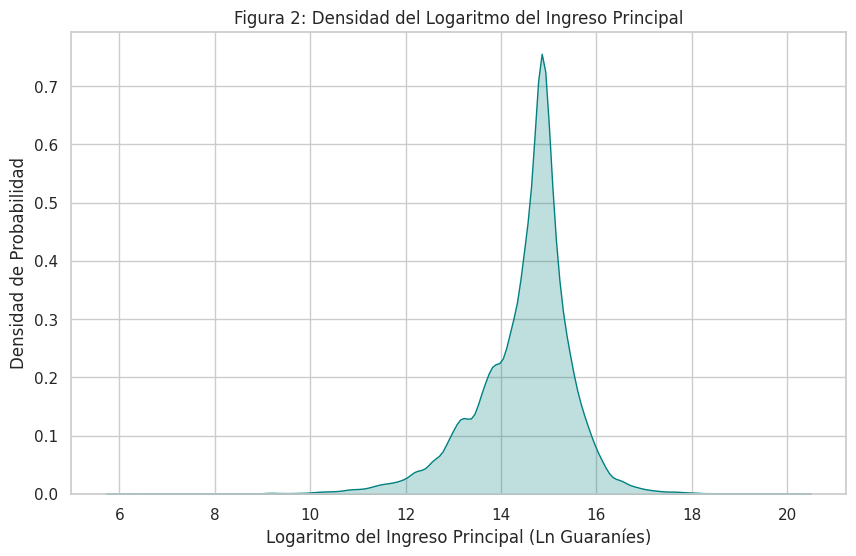

In [46]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_pea['LN_INGPRINC'].dropna(), fill=True, color='teal')
plt.title('Figura 2: Densidad del Logaritmo del Ingreso Principal')
plt.xlabel('Logaritmo del Ingreso Principal (Ln Guaraníes)')
plt.ylabel('Densidad de Probabilidad')
plt.show()

###Interpretación: La transformación logarítmica suaviza la asimetría extrema observada en los ingresos originales, aproximando la distribución hacia una forma simétrica y unimodal apta para modelos estadísticos.

#### Figura 3: Diagrama de Caja del Log(Ingreso) según Nivel Educativo

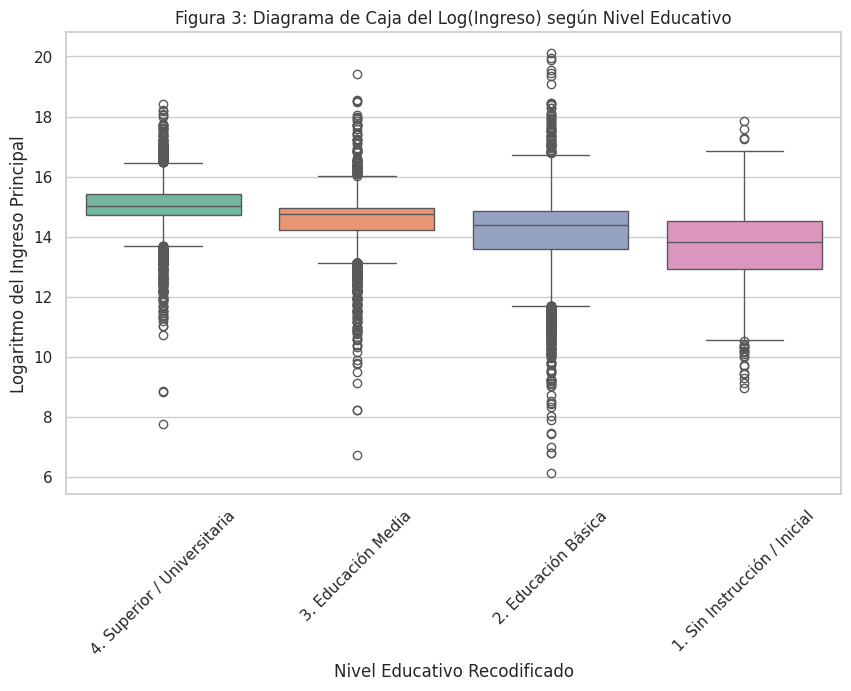

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_pea, x='NIVEL_EDUCATIVO_REC', y='LN_INGPRINC', hue='NIVEL_EDUCATIVO_REC', palette='Set2', legend=False)
plt.title('Figura 3: Diagrama de Caja del Log(Ingreso) según Nivel Educativo')
plt.xlabel('Nivel Educativo Recodificado')
plt.ylabel('Logaritmo del Ingreso Principal')
plt.xticks(rotation=45)
plt.show()

###Interpretación: Se observa un incremento escalonado en la mediana del log-ingreso a medida que aumenta el nivel educativo formal, evidenciando retornos salariales positivos asociados a la educación.

#### Figura 4: Dispersión entre la Edad y el Logaritmo del Ingreso

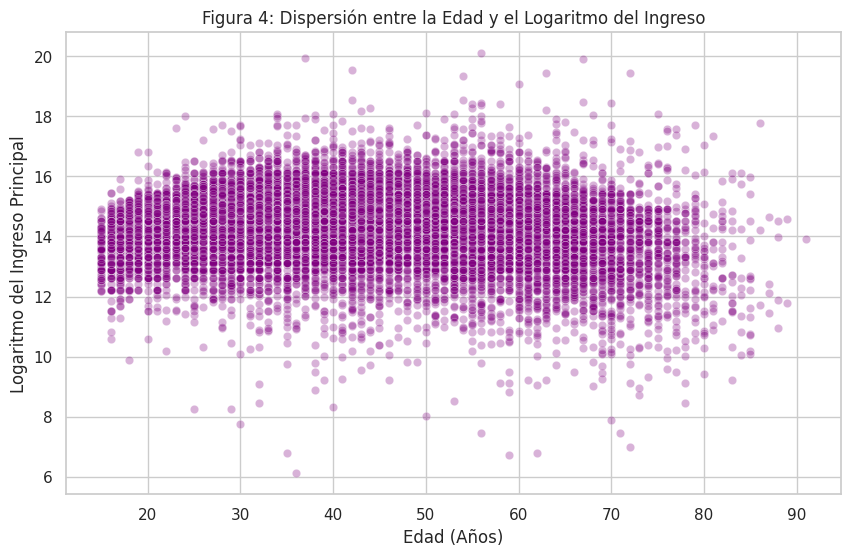

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pea, x='P02', y='LN_INGPRINC', alpha=0.3, color='purple')
plt.title('Figura 4: Dispersión entre la Edad y el Logaritmo del Ingreso')
plt.xlabel('Edad (Años)')
plt.ylabel('Logaritmo del Ingreso Principal')
plt.show()

###Interpretación: El gráfico muestra una dispersión amplia de los ingresos a lo largo de las diferentes edades, con una concentración mayor en la etapa central de la vida laboral activa (entre los 25 y 55 años).

#### Figura 5: Ingreso Promedio según Tramo de Edad y Área de Residencia

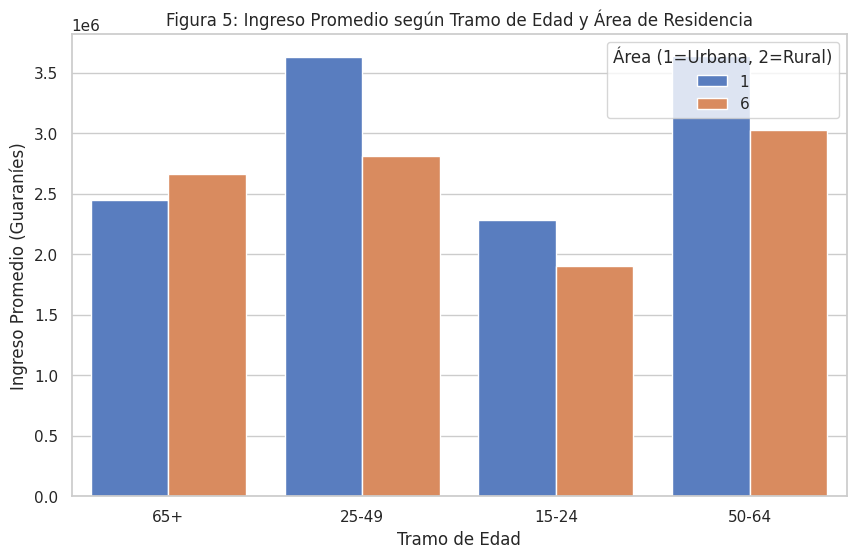

In [49]:
plt.figure(figsize=(10, 6))
# Se reemplaza 'ci=None' por 'errorbar=None' para evitar advertencias de depreciación
sns.barplot(data=df_pea, x='TRAMO_EDAD', y='INGPRINC', hue='AREA', errorbar=None, palette='muted')
plt.title('Figura 5: Ingreso Promedio según Tramo de Edad y Área de Residencia')
plt.xlabel('Tramo de Edad')
plt.ylabel('Ingreso Promedio (Guaraníes)')
plt.legend(title='Área (1=Urbana, 2=Rural)')
plt.show()

###Interpretación: Permite comparar visualmente las remuneraciones promedio, destacando una brecha favorable hacia el área urbana en comparación con la rural en prácticamente todos los tramos etarios.

#### Figura 6: Mapa de Calor de la Matriz de Correlación

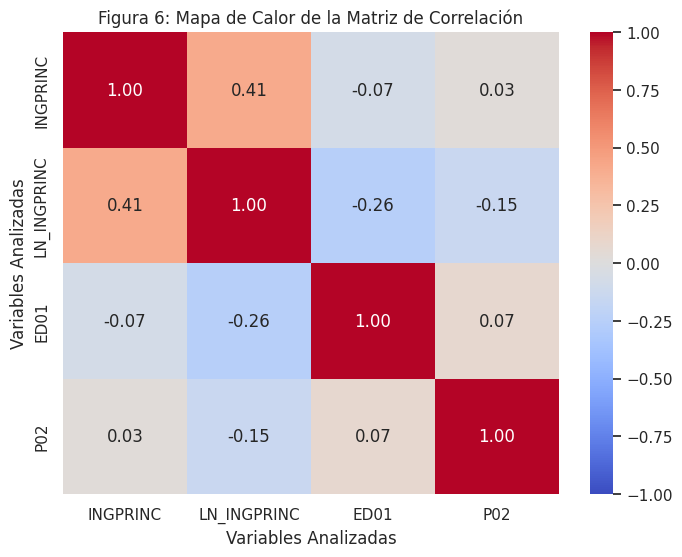

In [50]:
cols_corr = ['INGPRINC', 'LN_INGPRINC', 'ED01', 'P02']
corr_matrix = df_pea[cols_corr].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Figura 6: Mapa de Calor de la Matriz de Correlación')
plt.xlabel('Variables Analizadas')
plt.ylabel('Variables Analizadas')
plt.show()

###Interpretación: La matriz confirma una correlación positiva moderada entre el ingreso original y su versión logarítmica, mientras que las relaciones con la edad y la escolaridad codificada presentan asociaciones lineales débiles.

#### Figura 7: Tendencia del Ingreso Promedio según la Edad

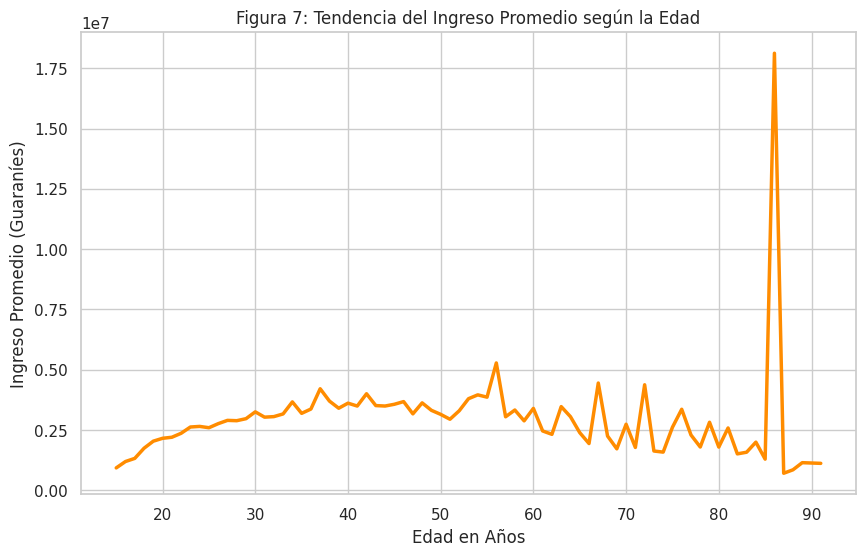

In [51]:
df_tendencia = df_pea.groupby('P02')['INGPRINC'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_tendencia, x='P02', y='INGPRINC', color='darkorange', linewidth=2.5)
plt.title('Figura 7: Tendencia del Ingreso Promedio según la Edad')
plt.xlabel('Edad en Años')
plt.ylabel('Ingreso Promedio (Guaraníes)')
plt.show()

###Interpretación: La línea de tendencia describe una curva ascendente desde la juventud, alcanzando  su punto máximo en la madurez laboral y experimentando un descenso gradual en edades avanzadas.

#### Figura 8: Composición Porcentual del Nivel Educativo por Tramo Etario

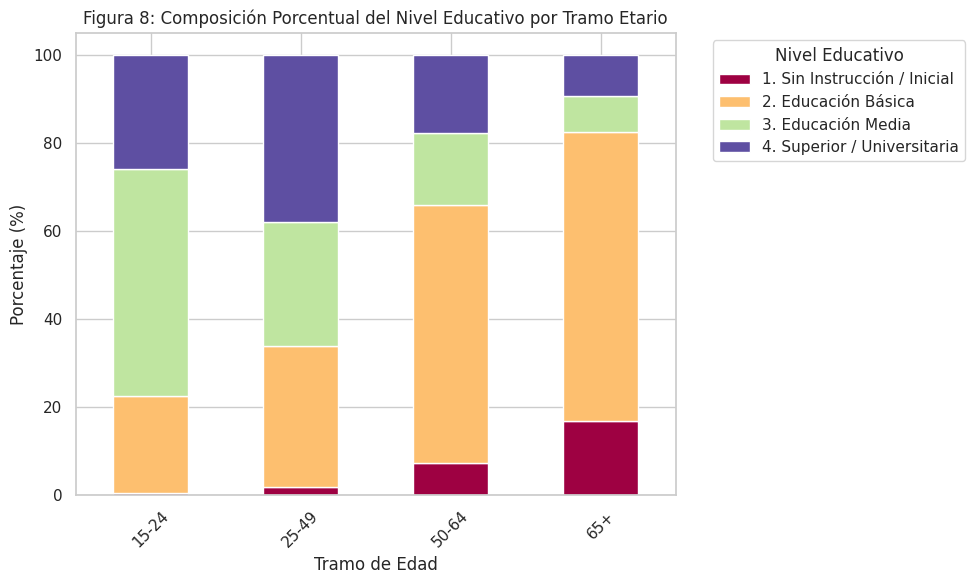

In [52]:
crosstab_edu = pd.crosstab(df_pea['TRAMO_EDAD'], df_pea['NIVEL_EDUCATIVO_REC'], normalize='index') * 100
crosstab_edu.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Spectral')
plt.title('Figura 8: Composición Porcentual del Nivel Educativo por Tramo Etario')
plt.xlabel('Tramo de Edad')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Nivel Educativo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Interpretación: Muestra la estructura generacional de la educación, evidenciando una mayor proporción de títulos superiores en las generaciones más jóvenes en contraste con los tramos de